In [14]:
import sys, pathlib
NB_DIR = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / "src" / "config.py").exists()), None)
print("Notebook dir:", NB_DIR)
print("Project root:", PROJECT_ROOT)

from pathlib import Path
from src.config import data_dir

RAW_DIR = Path(data_dir("raw")); RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR = Path(data_dir("processed")); PROC_DIR.mkdir(parents=True, exist_ok=True)


Notebook dir: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\notebooks
Project root: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model


In [2]:
import sys, pathlib
# add project root to sys.path so imports work
NB_DIR = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / "src" / "config.py").exists()), None)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import load_env, data_dir
load_env()

print("Notebook CWD:", NB_DIR)
print("RAW (absolute):", pathlib.Path(data_dir("raw")).resolve())
print("PROC (absolute):", pathlib.Path(data_dir("processed")).resolve())


Notebook CWD: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\notebooks
RAW (absolute): C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\raw
PROC (absolute): C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed


In [13]:
from pathlib import Path
from src.config import data_dir

# canonical project-level data dirs (from src/config.py)
proj_raw  = Path(data_dir("raw"))
proj_proc = Path(data_dir("processed"))
proj_raw.mkdir(parents=True, exist_ok=True)
proj_proc.mkdir(parents=True, exist_ok=True)

# stray notebooks/data (relative to where the notebook lives)
nb_data = Path.cwd() / "data"   # <-- this is notebooks/data if it exists

moved = []
if nb_data.exists() and nb_data.is_dir():
    for p in nb_data.rglob("*"):
        if p.is_file():
            # csv → raw, others → processed
            target = proj_raw / p.name if p.suffix.lower() == ".csv" else proj_proc / p.name
            target.parent.mkdir(parents=True, exist_ok=True)
            p.replace(target)
            moved.append((p, target))

print(f"Moved {len(moved)} file(s) into project-level data/.")
for _, dst in moved:
    print(" ->", dst)

print("\nFinal structure check:")
print("Raw folder:", proj_raw, "contains", len(list(proj_raw.glob('*'))), "files")
print("Processed folder:", proj_proc, "contains", len(list(proj_proc.glob('*'))), "files")

from pathlib import Path
from src.config import data_dir

RAW_DIR  = Path(data_dir("raw"));       RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR = Path(data_dir("processed")); PROC_DIR.mkdir(parents=True, exist_ok=True)

# example save
import pandas as pd
test = pd.DataFrame({"ok":[1,2,3]})
test_fp = RAW_DIR / "path_check.csv"
test.to_csv(test_fp, index=False)
print("Wrote:", test_fp.resolve())


Moved 0 file(s) into project-level data/.

Final structure check:
Raw folder: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\raw contains 21 files
Processed folder: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed contains 8 files
Wrote: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\raw\path_check.csv


In [4]:
# src/config.py
import os
from pathlib import Path
from dotenv import load_dotenv, find_dotenv



# safe inside notebooks too
from pathlib import Path
if "__file__" in globals():
    PROJECT_ROOT = Path(__file__).resolve().parents[1]
else:
    # notebook: search upwards for src/config.py
    NB_DIR = Path.cwd().resolve()
    PROJECT_ROOT = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / "src" / "config.py").exists()), NB_DIR)


def load_env(dotenv_path: str | None = None) -> None:
    path = dotenv_path or find_dotenv(usecwd=True)
    load_dotenv(path, override=False)

def get_key(name: str, default: str | None = None, required: bool = False) -> str | None:
    val = os.getenv(name, default)
    if required and val is None:
        raise KeyError(f"Missing required environment variable: {name}")
    return val

def _resolve_from_root(rel: str) -> Path:
    p = Path(rel)
    return p if p.is_absolute() else (PROJECT_ROOT / p)

def data_dir(kind: str = "root") -> str:
    load_env()
    base = _resolve_from_root(get_key("DATA_DIR", "data"))
    if kind == "raw":
        raw = get_key("DATA_DIR_RAW", None)
        return str(_resolve_from_root(raw) if raw else (base / "raw"))
    if kind == "processed":
        proc = get_key("DATA_DIR_PROCESSED", None)
        return str(_resolve_from_root(proc) if proc else (base / "processed"))
    return str(base)


In [36]:
from src.config import data_dir, load_env
from pathlib import Path
load_env()
print("RAW:", data_dir("raw"))
print("PROC:", data_dir("processed"))
print("RAW exists:", Path(data_dir("raw")).exists())
print("PROC exists:", Path(data_dir("processed")).exists())


RAW: ./data/raw
PROC: ./data/processed
RAW exists: True
PROC exists: True


In [7]:
#  Stage 2:environment check 
import sys, pathlib
from datetime import datetime

# ensure project root (folder that contains src/) is on sys.path
NB_DIR = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / "src" / "config.py").exists()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Couldn't find src/config.py. Is this notebook inside your project?")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print("Notebook in:", NB_DIR)
print("Project root:", PROJECT_ROOT)

# config + env
from src.config import load_env, data_dir, get_key
load_env()
print("DATA_DIR:", data_dir())
print("RAW_DIR:", data_dir("raw"))
print("PROCESSED_DIR:", data_dir("processed"))
print("API_KEY_DUMMY present:", get_key("API_KEY_DUMMY") is not None)


Notebook in: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\notebooks
Project root: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model
DATA_DIR: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data
RAW_DIR: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\raw
PROCESSED_DIR: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed
API_KEY_DUMMY present: True


In [8]:
# Stage 3: dummy dataset
import pandas as pd

df = pd.DataFrame({
    "risk_level": [1, 2, 3, 4, 5],
    "revenue":    [10, 18, 25, 28, 26],
})

display(df)               # quick peek
print(df.info())          # schema check


,risk_level,revenue
0,1,10
1,2,18
2,3,25
3,4,28
4,5,26


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   risk_level  5 non-null      int64
 1   revenue     5 non-null      int64
dtypes: int64(2)
memory usage: 212.0 bytes
None


dot(risk, revenue): 363.0
corr(risk, revenue): 0.897
rev_delta summary: {'mean': 4.0, 'std': 4.546060565661952, 'min': -2.0, 'max': 8.0}
revenue summary:   {'mean': 21.4, 'std': 7.4027022093287, 'min': 10.0, 'max': 28.0}


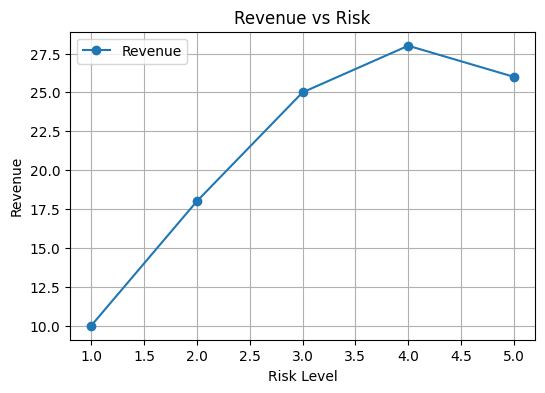

,risk_level,revenue,rev_prev,rev_delta
0,1,10,NaN,NaN
1,2,18,10.0,8.0
2,3,25,18.0,7.0
3,4,28,25.0,3.0
4,5,26,28.0,-2.0


In [9]:
# Stage 3: NumPy fundamentals, stats function & plot
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# NumPy arrays (cast revenue to float so NaN is allowed)
risk = df["risk_level"].to_numpy()
rev  = df["revenue"].to_numpy(dtype=float)

# previous revenue & delta
rev_prev = np.roll(rev, 1); rev_prev[0] = np.nan
rev_delta = np.diff(rev, prepend=np.nan)

# metrics
dot_prod = risk @ rev
corr     = float(np.corrcoef(risk, rev)[0, 1])

# attach back
df["rev_prev"]  = rev_prev
df["rev_delta"] = rev_delta

# small reusable function
def summarize_column(series: pd.Series) -> dict:
    return {
        "mean": float(series.mean()),
        "std":  float(series.std()),
        "min":  float(series.min()),
        "max":  float(series.max()),
    }

print("dot(risk, revenue):", dot_prod)
print("corr(risk, revenue):", round(corr, 3))
print("rev_delta summary:", summarize_column(df["rev_delta"]))
print("revenue summary:  ", summarize_column(df["revenue"]))

# quick visualization
plt.figure(figsize=(6,4))
plt.plot(df["risk_level"], df["revenue"], marker="o", label="Revenue")
plt.xlabel("Risk Level")
plt.ylabel("Revenue")
plt.title("Revenue vs Risk")
plt.grid(True); plt.legend(); plt.show()

df  # show enriched table


In [10]:
###  reusable function
def summarize_column(series):
    """Return summary stats for a pandas Series."""
    return {
        "mean": series.mean(),
        "std": series.std(),
        "min": series.min(),
        "max": series.max()
    }

# Apply to our new columns
print("Summary of revenue deltas:")
print(summarize_column(df["rev_delta"]))

print("\nSummary of revenues:")
print(summarize_column(df["revenue"]))


Summary of revenue deltas:
{'mean': np.float64(4.0), 'std': np.float64(4.546060565661952), 'min': np.float64(-2.0), 'max': np.float64(8.0)}

Summary of revenues:
{'mean': np.float64(21.4), 'std': np.float64(7.4027022093287), 'min': np.int64(10), 'max': np.int64(28)}


In [15]:
# ---- Stages 4–5 (one-flow) — API ingest (5 banks) + VaR risk + CSV/Parquet + reload ----

df.to_csv(RAW_DIR / "banks_var_20250821.csv", index=False)

import pandas as pd, numpy as np, pathlib, glob, requests
from datetime import datetime
from src.config import data_dir, load_env

# ---------- setup ----------
load_env()
RAW_DIR  = pathlib.Path(data_dir("raw"));      RAW_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR = pathlib.Path(data_dir("processed")); PROC_DIR.mkdir(parents=True, exist_ok=True)

def ts() -> str: return datetime.now().strftime("%Y%m%d-%H%M")

def validate_df(df: pd.DataFrame, required_cols: list[str]) -> None:
    missing = [c for c in required_cols if c not in df.columns]
    if missing: raise ValueError(f"Missing columns: {missing}")
    print("Shape:", df.shape)
    print("NA counts:\n", df.isna().sum())

def save_raw(df: pd.DataFrame, prefix: str) -> pathlib.Path:
    fp = RAW_DIR / f"{prefix}_{ts()}.csv"
    df.to_csv(fp, index=False)
    print("Saved:", fp)
    return fp

# ---------- Stage 4: API acquisition (1y daily, 5 banks), tidy → validate → save raw ----------
import yfinance as yf

banks = {"JPM":"JPMorgan Chase","MS":"Morgan Stanley","DB":"Deutsche Bank","GS":"Goldman Sachs","BAC":"Bank of America"}
raw = yf.download(list(banks.keys()), period="1y", interval="1d", group_by="ticker", auto_adjust=True, threads=True)

# reshape robustly to tidy: date, ticker, adj_close, volume
rows = []
for t in banks.keys():
    try:
        tdf = raw[t].reset_index()[["Date","Close","Volume"]].copy()  # MultiIndex case
    except (KeyError, AttributeError):
        # fallback if yfinance returns flat columns
        tdf = raw.reset_index()[["Date","Close","Volume"]].copy()
    tdf["ticker"] = t
    rows.append(tdf)
prices = (pd.concat(rows, ignore_index=True)
            .rename(columns={"Date":"date","Close":"adj_close","Volume":"volume"})
            .sort_values(["ticker","date"])
            .reset_index(drop=True))

validate_df(prices, ["date","ticker","adj_close","volume"])
prices_fp = save_raw(prices, "api_yf_bank_prices")
display(prices.head())

# ---------- Stage 5: build VaR-based risk index + sample revenue; save CSV & Parquet ----------
# log returns per ticker
prices["log_ret"] = np.log(prices["adj_close"] / prices.groupby("ticker")["adj_close"].shift(1))

# 30D historical VaR(95%) per ticker (positive loss magnitude)
def var95(s: pd.Series) -> float:
    if s.isna().all(): return np.nan
    p5 = np.nanpercentile(s, 5)
    return float(-p5)

prices["VaR95_30d"] = (
    prices.groupby("ticker")["log_ret"]
          .rolling(30, min_periods=20)
          .apply(var95, raw=False)
          .reset_index(level=0, drop=True)
)

# aggregate across tickers → daily risk index (mean VaR)
risk_by_day = (
    prices.dropna(subset=["VaR95_30d"])
          .groupby("date")["VaR95_30d"]
          .mean()
          .rename("risk_index_var95")
          .reset_index()
)

# simple revenue proxy that decreases with risk (so you can proceed to Stage 6 modeling/cleaning)
rng = np.random.default_rng(42)
sample = risk_by_day.copy()
sample["revenue"] = 100 - 500*sample["risk_index_var95"] + rng.normal(0, 1.5, size=len(sample))

# save processed (CSV + Parquet)
csv_path = PROC_DIR / f"revrisk_var95_sample_{ts()}.csv"
pq_path  = PROC_DIR / f"revrisk_var95_sample_{ts()}.parquet"
sample.to_csv(csv_path, index=False)
sample.to_parquet(pq_path, index=False)
print("Wrote processed:", csv_path.name, "and", pq_path.name)
display(sample.head())

# ---------- Stage 5 extras: tiny IO utilities + reload/validate ----------
def write_df(df: pd.DataFrame, path: pathlib.Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    suf = path.suffix.lower()
    if suf == ".csv":
        df.to_csv(path, index=False)
    elif suf in (".parquet", ".pq"):
        df.to_parquet(path, index=False)
    else:
        raise ValueError(f"Unsupported file type: {suf}")
    print("Wrote:", path)

def read_df(path: pathlib.Path) -> pd.DataFrame:
    if not path.exists(): raise FileNotFoundError(path)
    suf = path.suffix.lower()
    if suf == ".csv":
        # parse 'date' if present
        head_cols = pd.read_csv(path, nrows=0).columns
        return pd.read_csv(path, parse_dates=["date"]) if "date" in head_cols else pd.read_csv(path)
    elif suf in (".parquet", ".pq"):
        return pd.read_parquet(path)
    else:
        raise ValueError(f"Unsupported file type: {suf}")

re_csv  = read_df(csv_path)
re_parq = read_df(pq_path)
print("Reloaded shapes:", re_csv.shape, re_parq.shape)
print("Columns:", re_csv.columns.tolist()[:6], "...")


[*********************100%***********************]  5 of 5 completed


Shape: (1255, 4)
NA counts:
 Price
date         0
adj_close    0
volume       0
ticker       0
dtype: int64
Saved: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\raw\api_yf_bank_prices_20250821-1050.csv


Price,date,adj_close,volume,ticker
0,2024-08-21,37.823040,33751100,BAC
1,2024-08-22,38.301323,35421600,BAC
2,2024-08-23,38.818642,45616600,BAC
3,2024-08-26,38.965050,44659500,BAC
4,2024-08-27,38.721031,32323900,BAC


Wrote processed: revrisk_var95_sample_20250821-1050.csv and revrisk_var95_sample_20250821-1050.parquet


,date,risk_index_var95,revenue
0,2024-09-19,0.028366,86.274261
1,2024-09-20,0.028740,84.070262
2,2024-09-23,0.028210,87.020492
3,2024-09-24,0.027693,87.564164
4,2024-09-25,0.027170,83.488303


Reloaded shapes: (231, 3) (231, 3)
Columns: ['date', 'risk_index_var95', 'revenue'] ...


In [12]:
from pathlib import Path
from src.config import data_dir

nb_data = Path.cwd() / "data"          # notebooks/data (if it exists)
proj_raw = Path(data_dir("raw")); proj_raw.mkdir(parents=True, exist_ok=True)
proj_proc = Path(data_dir("processed")); proj_proc.mkdir(parents=True, exist_ok=True)

moved = 0
if nb_data.exists():
    for p in nb_data.rglob("*"):
        if p.is_file():
            target = proj_raw / p.name if p.suffix.lower()==".csv" else proj_proc / p.name
            p.replace(target)
            moved += 1
print(f"Moved files: {moved}")


Moved files: 0


In [17]:
from pathlib import Path
import pandas as pd
from src.config import data_dir

RAW_DIR  = Path(data_dir("raw"))
PROC_DIR = Path(data_dir("processed"))

#  latest processed CSV
p_csvs = sorted(PROC_DIR.glob("revrisk_var95_sample_*.csv"))
p_pars = sorted(PROC_DIR.glob("revrisk_var95_sample_*.parquet"))

print("RAW dir:", RAW_DIR.resolve())
print("PROC dir:", PROC_DIR.resolve())
print("Found processed CSV:", p_csvs[-1] if p_csvs else "None")
print("Found processed PARQUET:", p_pars[-1] if p_pars else "None")

def read_df(path: Path) -> pd.DataFrame:
    if path.suffix.lower()==".csv":
        cols = pd.read_csv(path, nrows=0).columns
        return pd.read_csv(path, parse_dates=["date"]) if "date" in cols else pd.read_csv(path)
    elif path.suffix.lower() in (".parquet",".pq"):
        return pd.read_parquet(path)
    raise ValueError("Unsupported file type")

if p_csvs and p_pars:
    dfc = read_df(p_csvs[-1])
    dfp = read_df(p_pars[-1])
    print("CSV shape/dtypes:\n", dfc.shape, "\n", dfc.dtypes)
    print("\nPARQUET shape/dtypes:\n", dfp.shape, "\n", dfp.dtypes)
else:
    print("Missing processed files — rerun the Stages 4–5 one‑flow cell.")


RAW dir: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\raw
PROC dir: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed
Found processed CSV: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed\revrisk_var95_sample_20250821-1050.csv
Found processed PARQUET: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed\revrisk_var95_sample_20250821-1050.parquet
CSV shape/dtypes:
 (231, 3) 
 date                datetime64[ns]
risk_index_var95           float64
revenue                    float64
dtype: object

PARQUET shape/dtypes:
 (231, 3) 
 date                datetime64[ns]
risk_index_var95           float64
revenue                    float64
dtype: object


In [18]:
# Stage 6: data preprocessing & cleaning
import pathlib, sys

NB_DIR = pathlib.Path.cwd().resolve()
PROJECT_ROOT = next((p for p in [NB_DIR, *NB_DIR.parents] if (p / "src" / "config.py").exists()), None)
assert PROJECT_ROOT is not None, "Can't find project root (missing src/config.py?)"

cleaning_py = PROJECT_ROOT / "src" / "cleaning.py"
cleaning_py.write_text(
"""# src/cleaning.py
import pandas as pd
from sklearn.preprocessing import StandardScaler

def fill_missing_median(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    for c in cols:
        if c in out.columns:
            out[c] = out[c].fillna(out[c].median())
    return out

def drop_missing(df: pd.DataFrame, cols: list[str], thresh: float = 0.5) -> pd.DataFrame:
    \"\"\"Drop rows where the fraction of NA among `cols` exceeds `thresh`.\"\"\" 
    out = df.copy()
    frac_na = out[cols].isna().mean(axis=1)
    return out.loc[frac_na <= thresh].reset_index(drop=True)

def normalize_data(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    out = df.copy()
    scaler = StandardScaler()
    out[cols] = scaler.fit_transform(out[cols])
    return out
""",
encoding="utf-8"
)
print("Wrote:", cleaning_py)


Wrote: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\src\cleaning.py


In [20]:
# with latest dataset
import pandas as pd, glob, pathlib
from src.config import data_dir

PROC_DIR = pathlib.Path(data_dir("processed"))
latest_csv = sorted(PROC_DIR.glob("revrisk_var95_sample_*.csv"))[-1]  # use your VaR dataset
df = pd.read_csv(latest_csv, parse_dates=["date"])

# (optional) simulate a few missings to demonstrate cleaning
df.loc[::25, "revenue"] = None

before = {
    "file": str(latest_csv),
    "shape": df.shape,
    "na_counts": df.isna().sum().to_dict(),
    "desc": df[["risk_index_var95","revenue"]].describe(include="all").to_dict(),
}
print("BEFORE:", before["file"])
print("Shape:", before["shape"])
print("NA counts:", before["na_counts"])
df.head(3)


BEFORE: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed\revrisk_var95_sample_20250821-1050.csv
Shape: (231, 3)
NA counts: {'date': 0, 'risk_index_var95': 0, 'revenue': 10}


,date,risk_index_var95,revenue
0,2024-09-19,0.028366,NaN
1,2024-09-20,0.028740,84.070262
2,2024-09-23,0.028210,87.020492


In [21]:
# Stage 6: applying cleaning & comparison
from src.cleaning import fill_missing_median, drop_missing, normalize_data
from datetime import datetime

def ts(): return datetime.now().strftime("%Y%m%d-%H%M")

# choose numeric columns to clean/scale
num_cols = ["risk_index_var95", "revenue"]

# pipeline: fill → drop (if too many NA) → scale
clean1 = fill_missing_median(df, ["revenue"])
clean2 = drop_missing(clean1, num_cols, thresh=0.9)   # keep rows with ≤90% NA in selected cols
clean3 = normalize_data(clean2, num_cols)

after = {
    "shape": clean3.shape,
    "na_counts": clean3.isna().sum().to_dict(),
    "desc": clean3[num_cols].describe().to_dict(),
}
print("AFTER")
print("Shape:", after["shape"])
print("NA counts:", after["na_counts"])

# save cleaned to processed
from pathlib import Path
CLEAN_PATH = Path(data_dir("processed")) / f"revrisk_var95_cleaned_{ts()}.parquet"
clean3.to_parquet(CLEAN_PATH, index=False)
print("Saved cleaned:", CLEAN_PATH)

# quick peek
clean3.head(3)


AFTER
Shape: (231, 3)
NA counts: {'date': 0, 'risk_index_var95': 0, 'revenue': 0}
Saved cleaned: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed\revrisk_var95_cleaned_20250821-1111.parquet


,date,risk_index_var95,revenue
0,2024-09-19,0.150293,0.358175
1,2024-09-20,0.174550,-0.380576
2,2024-09-23,0.140220,0.002945


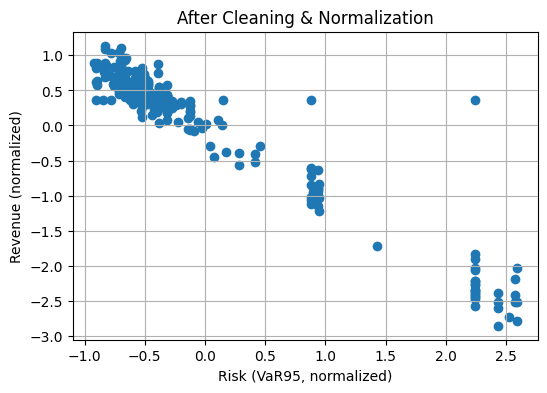

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(clean3["risk_index_var95"], clean3["revenue"])
plt.xlabel("Risk (VaR95, normalized)")
plt.ylabel("Revenue (normalized)")
plt.title("After Cleaning & Normalization")
plt.grid(True)
plt.show()
